Bibliotecas

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

carregando datasets (umm dataset contém dados de vinho branco e outro de vinho tinto)

In [ ]:
# carregando datasets (vinho branco)
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", sep=';')

print("White wine shape:", df.shape)

df.head()

White wine shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Removendo duplicatas

In [ ]:
df = df.drop_duplicates()
df.shape

(3961, 12)

Normalização min-max

In [ ]:
df_norm = (df - df.min()) / (df.max() - df.min())

Binarizando o atributo alvo (quality)


In [ ]:
# binarizando com limiar = 6
df['quality_binary'] = (df['quality'] >= 6).astype(int)

# contagem absoluta
print(df['quality_binary'].value_counts())

# contagem com proporções
print(df['quality_binary'].value_counts(normalize=True))

# total de instâncias
print("Total:", df['quality_binary'].shape[0])


quality_binary
1    2613
0    1348
Name: count, dtype: int64
quality_binary
1    0.659682
0    0.340318
Name: proportion, dtype: float64
Total: 3961


Remoção de outliers

In [ ]:
# remoção de outliers
num_cols = df.select_dtypes(include='number').columns

mask = pd.Series(True, index=df.index)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask &= (df[col] >= lower) & (df[col] <= upper)

df_filtered = df[mask]


# contagem absoluta
print(df['quality_binary'].value_counts())

# contagem com proporções
print(df['quality_binary'].value_counts(normalize=True))

# total de instâncias
print("Total:", df['quality_binary'].shape[0])

quality_binary
1    2613
0    1348
Name: count, dtype: int64
quality_binary
1    0.659682
0    0.340318
Name: proportion, dtype: float64
Total: 3961


Remoção dos atributos 'density' e 'total sulfur dioxide'

In [ ]:
df = df.drop(columns=['density', 'total sulfur dioxide'])

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report

In [ ]:
X = df.drop(columns=['quality', 'quality_binary'])
y = df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=37
)

GridSearch

In [ ]:
modelos = {
    "Regressão Logística": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "model__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
            "model__class_weight": [None, "balanced"],
            "model__solver": ["lbfgs", "liblinear"]
        }
    },

    "MLP": {
        "model": MLPClassifier(max_iter=1000, random_state=37),
        "params": {
              "model__hidden_layer_sizes": [
                  (50,), (100,), (200,),
                  (100,50), (150,100), (200,100),
                  (100,100)
              ],
              "model__activation": ["relu", "tanh", "logistic"],
              "model__alpha": [0.00001, 0.0001, 0.001, 0.01],
              "model__learning_rate_init": [0.0005, 0.001, 0.01]
        }

    },

    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {}
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)

resultados = {}

for nome, config in modelos.items():

    print(f"\n===============================")
    print(f"Tuning do modelo: {nome}")
    print(f"===============================\n")

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=37)),
        ('model', config["model"])
    ])

    # Se houver hiperparâmetros → GridSearch
    if config["params"]:

        grid = GridSearchCV(
            pipeline,
            config["params"],
            cv=cv,
            scoring='f1',
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params = grid.best_params_
        best_score = grid.best_score_

        print("Melhor F1 na validação:", best_score)
        print("Melhores parâmetros:", best_params)

    # Se não houver hiperparâmetros → apenas treina
    else:
        best_model = pipeline.fit(X_train, y_train)
        best_params = "N/A"
        best_score = "N/A"

    # ========================
    # AVALIAÇÃO NO TESTE
    # ========================

    y_pred = best_model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    print("F1 no conjunto de teste:", f1)
    print(classification_report(y_test, y_pred))

    resultados[nome] = {
        "F1 Validação": best_score,
        "F1 Teste": f1,
        "Parâmetros": best_params,
        "Modelo": best_model
    }

df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values(by="F1 Teste", ascending=False)

print("\nRanking final (baseado no conjunto de teste):")
print(df_resultados.drop(columns="Modelo"))


Apenas MLP

In [ ]:
melhores_params_mlp = {
    'model__activation': 'relu',
    'model__alpha': 0.0001,
    'model__hidden_layer_sizes': (500,),
    'model__learning_rate_init': 0.0005
}

mlp_model = MLPClassifier(
    max_iter=1000,
    random_state=37,
)

pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=37)),
    ('model', mlp_model)
])

pipeline_mlp.set_params(**melhores_params_mlp)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)

f1_scores_cv = cross_val_score(
    pipeline_mlp,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

f1_validation = f1_scores_cv.mean()

print(f"F1 Score Médio na Validação Cruzada: {f1_validation:.4f}")
print("Treinando o modelo final no conjunto de treino completo")

pipeline_mlp.fit(X_train, y_train)

y_pred_mlp = pipeline_mlp.predict(X_test)
f1_teste = f1_score(y_test, y_pred_mlp)

print("Treinamento concluído.")

print(f"\n==========================================")
print(f"Avaliação Final - MLP")
print(f"==========================================")
print(f"Parâmetros utilizados: {melhores_params_mlp}")
print(f"F1 Score Validação (Média CV): {f1_validation:.4f}")
print(f"F1 Score no conjunto de Teste: {f1_teste:.4f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_mlp))

F1 Score Médio na Validação Cruzada: 0.8013
Treinando o modelo final no conjunto de treino completo
Treinamento concluído.

Avaliação Final - MLP
Parâmetros utilizados: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (500,), 'model__learning_rate_init': 0.0005}
F1 Score Validação (Média CV): 0.8013
F1 Score no conjunto de Teste: 0.8124

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.63      0.67      0.65       270
           1       0.83      0.80      0.81       523

    accuracy                           0.76       793
   macro avg       0.73      0.74      0.73       793
weighted avg       0.76      0.76      0.76       793



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearch apenas com Regressão Logística

In [ ]:
# Configurações para a Regressão Logística
config_logreg = {
    "model": LogisticRegression(max_iter=5000, random_state=37), # Aumentando max_iter para solvers mais complexos
    "params": {
        # 1. Expandindo o range de C (mais exaustivo)
        "model__C": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        # 2. Adicionando a penalidade L1
        "model__penalty": ["l1", "l2"],
        # 3. Solvers que suportam L1 e L2
        "model__solver": ["liblinear", "saga"],
        "model__class_weight": [None, "balanced"]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)

nome_modelo = "Regressão Logística"

print(f"\n=============================================")
print(f"Iniciando GridSearch para: {nome_modelo}")
print(f"=============================================\n")

# Criação do Pipeline com os passos de pré-processamento e balanceamento
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=37)),
    ('model', config_logreg["model"])
])

# Configuração do GridSearchCV
grid_logreg = GridSearchCV(
    pipeline_logreg,
    config_logreg["params"],
    cv=cv, # Usa a StratifiedKFold definida anteriormente
    scoring='f1', # Otimiza o F1 Score
    n_jobs=-1,
    verbose=1
)

# Execução do GridSearch nos dados de treino
grid_logreg.fit(X_train, y_train)

# ===================================================
# Resultados do GridSearch (Validação Cruzada)
# ===================================================

best_model_logreg = grid_logreg.best_estimator_
best_params_logreg = grid_logreg.best_params_
best_score_logreg = grid_logreg.best_score_

print("\n--- Resultados de Validação ---")
print(f"Melhor F1 Score (Validação Cruzada): {best_score_logreg:.4f}")
print("Melhores Parâmetros:", best_params_logreg)

# ===================================================
# Avaliação Final no Conjunto de Teste
# ===================================================

print("\n--- Avaliação no Conjunto de Teste ---")
y_pred_logreg = best_model_logreg.predict(X_test)
f1_teste_logreg = f1_score(y_test, y_pred_logreg)

print(f"F1 Score no conjunto de teste: {f1_teste_logreg:.4f}")
print("\nRelatório de Classificação no Teste:")
print(classification_report(y_test, y_pred_logreg))


Iniciando GridSearch para: Regressão Logística

Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Resultados de Validação ---
Melhor F1 Score (Validação Cruzada): 0.7738
Melhores Parâmetros: {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'saga'}

--- Avaliação no Conjunto de Teste ---
F1 Score no conjunto de teste: 0.7894

Relatório de Classificação no Teste:
              precision    recall  f1-score   support

           0       0.59      0.73      0.66       270
           1       0.84      0.74      0.79       523

    accuracy                           0.74       793
   macro avg       0.72      0.74      0.72       793
weighted avg       0.76      0.74      0.74       793



curva roc auc

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, average_precision_score


modelos_finais = {

    "Regressão Logística": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=37)),
        ('model', LogisticRegression(
            C=1,
            class_weight=None,
            solver='lbfgs',
            max_iter=1000
        ))
    ]),

    "MLP": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=37)),
        ('model', MLPClassifier(
            activation='relu',
            alpha=0.0001,
            hidden_layer_sizes=(200,),
            learning_rate_init=0.0005,
            max_iter=1000,
            random_state=37
        ))
    ]),

    "Naive Bayes": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=37)),
        ('model', GaussianNB())
    ])
}

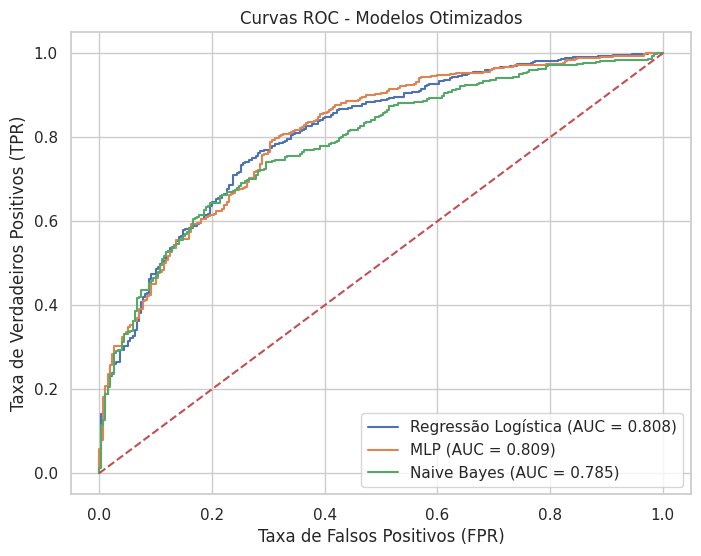

In [ ]:
plt.figure(figsize=(8,6))

for nome, modelo in modelos_finais.items():

    # treina modelo final com todos os dados de treino
    modelo.fit(X_train, y_train)

    # probabilidades da classe positiva (classe 1)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # AUC
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{nome} (AUC = {roc_auc:.3f})")

# linha de referência aleatória
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curvas ROC - Modelos Otimizados")
plt.legend()
plt.grid(True)
plt.show()

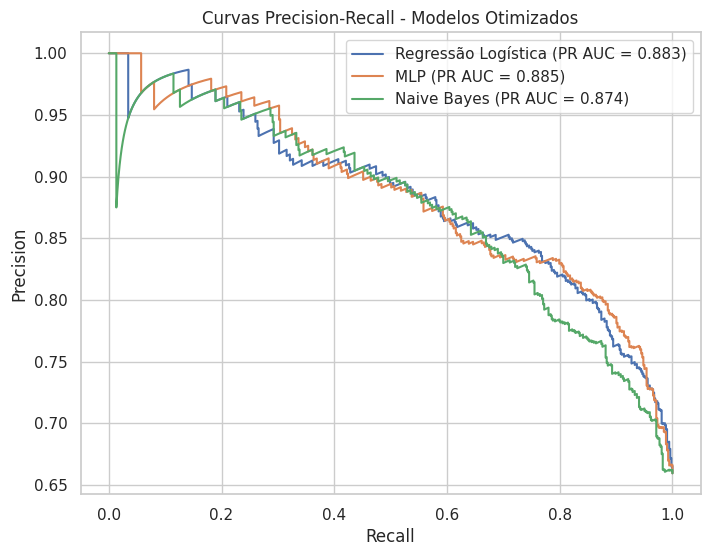

In [ ]:
plt.figure(figsize=(8,6))

for nome, modelo in modelos_finais.items():

    # Probabilidades da classe positiva
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    # PR AUC
    pr_auc = average_precision_score(y_test, y_prob)

    # Plot
    plt.plot(recall, precision, label=f"{nome} (PR AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall - Modelos Otimizados")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for nome, modelo in modelos_finais.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_prob)
    print(f"{nome} - PR AUC: {pr_auc:.4f}")

Regressão Logística - PR AUC: 0.8834
MLP - PR AUC: 0.8851
Naive Bayes - PR AUC: 0.8745


In [ ]:
from sklearn.metrics import roc_auc_score

for nome, modelo in modelos_finais.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"{nome} - ROC AUC: {auc_score:.4f}")

Regressão Logística - ROC AUC: 0.8077
MLP - ROC AUC: 0.8088
Naive Bayes - ROC AUC: 0.7853


In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=37)),
    ('model', MLPClassifier(
        activation='relu',
        alpha=0.0001,
        hidden_layer_sizes=(200,),
        learning_rate_init=0.0005,
        max_iter=1000,
        random_state=37
    ))
])

mlp_model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=37)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(200,),
                               learning_rate_init=0.0005, max_iter=1000,
                               random_state=37))])

  0%|          | 0/50 [00:00<?, ?it/s]

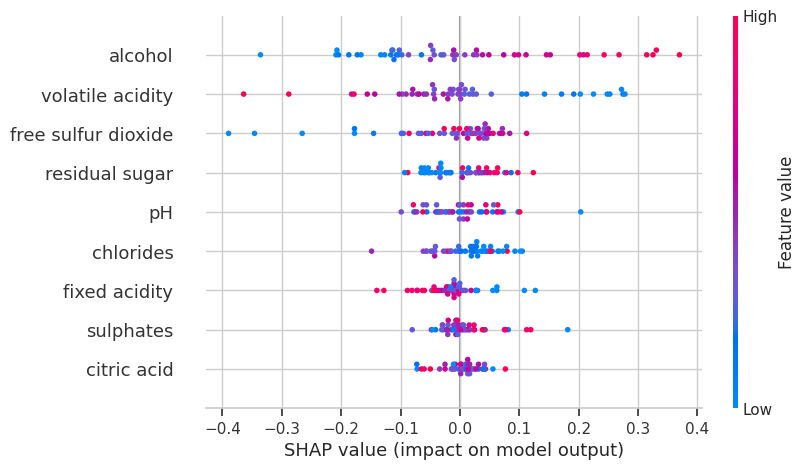

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
import shap
import pandas as pd
import numpy as np

# Normaliza os dados
X_train_scaled = mlp_model.named_steps['scaler'].transform(X_train)
X_test_scaled  = mlp_model.named_steps['scaler'].transform(X_test)

# Converte para DataFrame com os nomes reais das colunas
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)

# Extrai o modelo
model = mlp_model.named_steps['model']

# Inicializa o SHAP
explainer = shap.KernelExplainer(model.predict_proba, X_train_df[:100])

# Calcula valores SHAP
shap_values = explainer(X_test_scaled[:50])
shap.plots.beeswarm(shap_values[...,1])

# Seleciona classe positiva
shap_values_class1 = shap_values[1]

# Plota resumo com nomes reais
shap.summary_plot(shap_values_class1, X_test_df[:50], feature_names=X.columns)


